In [1]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
}

os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    import random
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

/Users/jasper.bruin/miniconda3/envs/driftwatch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
###############################################################################
# Drift Detection Class (using Cosine Similarity)
###############################################################################
import numpy as np

class EmbeddingTracker:
    def __init__(self, embedding_dim, alpha=0.01):
        """
        :param embedding_dim: Dimension of the embeddings.
        :param alpha: The update rate for the exponential moving average.
        """
        self.alpha = alpha
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

    def update(self, embedding):
        """
        Update the running mean of embeddings using an exponential moving average.
        """
        if self.count == 0:
            # Initialize mean with the first embedding
            self.mean = embedding
        else:
            # Exponential moving average update
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

        self.count += 1

    def cosine_similarity(self, embedding):
        """
        Compute the cosine similarity between a new embedding and the running mean.
        Cosine similarity = (A ⋅ B) / (||A|| * ||B||).
        """
        mean_norm = np.linalg.norm(self.mean)
        emb_norm = np.linalg.norm(embedding)

        # Handle edge cases where norms are zero
        if mean_norm == 0 or emb_norm == 0:
            return 0.0

        return np.dot(self.mean, embedding) / (mean_norm * emb_norm)



In [4]:

###############################################################################
# Main Data Collection
###############################################################################
def collect_data():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print("Using device:", device)

    from collections import defaultdict
    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"\n=== Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"\n--- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            key = (dataset_name, model_name)

            for drift_strength in args["drift_strengths"]:
                print(f"Simulating drift_strength={drift_strength} ...")
                drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)
                test_texts = baseline_texts + drifted_texts

                # No PCA
                embedding_dim_no_pca = baseline_embs.shape[1]
                tracker_no_pca = EmbeddingTracker(embedding_dim_no_pca, alpha=0.01)
                distance_scores_no_pca = []
                all_embeddings_no_pca = []

                # Initialize tracker with baseline
                for batch in batch_generator(baseline_texts, args["batch_size"]):
                    emb = extract_cls_embeddings(model, tokenizer, batch, device)
                    mean_emb = emb.mean(axis=0)
                    tracker_no_pca.update(mean_emb)

                for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                    emb = extract_cls_embeddings(model, tokenizer, batch, device)
                    all_embeddings_no_pca.extend(emb)
                    mean_emb = emb.mean(axis=0)
                    dist = tracker_no_pca.cosine_similarity(mean_emb)
                    distance_scores_no_pca.append(dist)
                    tracker_no_pca.update(mean_emb)

                final_dist_no_pca = distance_scores_no_pca[-1] if distance_scores_no_pca else 0.0

                # PCA
                embedding_dim_pca = args["pca_components"]
                tracker_pca = EmbeddingTracker(embedding_dim_pca, alpha=0.01)
                distance_scores_pca = []
                all_embeddings_pca = []

                # Initialize tracker with baseline (reduced)
                for batch in batch_generator(baseline_texts, args["batch_size"]):
                    emb = extract_cls_embeddings(model, tokenizer, batch, device)
                    emb_pca = pca.transform(emb)
                    mean_emb = emb_pca.mean(axis=0)
                    tracker_pca.update(mean_emb)

                for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                    emb = extract_cls_embeddings(model, tokenizer, batch, device)
                    emb_pca = pca.transform(emb)
                    all_embeddings_pca.extend(emb_pca)
                    mean_emb = emb_pca.mean(axis=0)
                    dist = tracker_pca.cosine_similarity(mean_emb)
                    distance_scores_pca.append(dist)
                    tracker_pca.update(mean_emb)

                final_dist_pca = distance_scores_pca[-1] if distance_scores_pca else 0.0

                # Store with 'final_similarity' key to avoid KeyError in plotting
                results[key].append({
                    "drift_strength": drift_strength,
                    "pca": False,
                    "time_series": distance_scores_no_pca[:],
                    "final_similarity": final_dist_no_pca,  # rename for plotting
                    "all_embeddings": np.array(all_embeddings_no_pca)
                })
                results[key].append({
                    "drift_strength": drift_strength,
                    "pca": True,
                    "time_series": distance_scores_pca[:],
                    "final_similarity": final_dist_pca,     # rename for plotting
                    "all_embeddings": np.array(all_embeddings_pca)
                })

    print("\nData collection done!")
    return results

all_results = collect_data()

Using device: mps

=== Loading dataset: yelp_review_full ===

--- Using Model: nlpaueb/sec-bert-base ---
Simulating drift_strength=0.0 ...


Simulating drift_strength=0.25 ...


Simulating drift_strength=0.5 ...


Simulating drift_strength=0.75 ...


Simulating drift_strength=1.0 ...


...

Simulating drift_strength=0.25 ...


Simulating drift_strength=0.5 ...


Simulating drift_strength=0.75 ...


Simulating drift_strength=1.0 ...



Data collection done!


defaultdict(<class 'list'>, {('yelp_review_full', 'nlpaueb/sec-bert-base'): [{'drift_strength': 0.0, 'pca': False, 'time_series': [np.float32(0.9999971), np.float32(0.9986412), np.float32(0.9988834), np.float32(0.9989432), np.float32(0.99850607), np.float32(0.999231), np.float32(0.9988409), np.float32(0.9990135), np.float32(0.99888563), np.float32(0.99862474), np.float32(0.9989637), np.float32(0.9987862), np.float32(0.9992255), np.float32(0.9991119), np.float32(0.9987038), np.float32(0.99871445)], 'final_similarity': np.float32(0.99871445), 'all_embeddings': array([[ 0.07525124,  0.38030824, -0.23352078, ...,  0.15591048,
        -0.09903064, -0.24518856],
       [-0.47753993,  0.14273493, -0.43694058, ...,  0.10741623,
         0.01783486, -0.58426285],
       [-0.19049984,  0.22282945, -0.22139257, ...,  0.3314596 ,
        -0.19684567, -0.7720277 ],
       ...,
       [-0.05676448,  0.27288446, -0.4818679 , ...,  0.11139075,
        -0.29510152, -0.10607041],
       [ 0.1826144 , -0

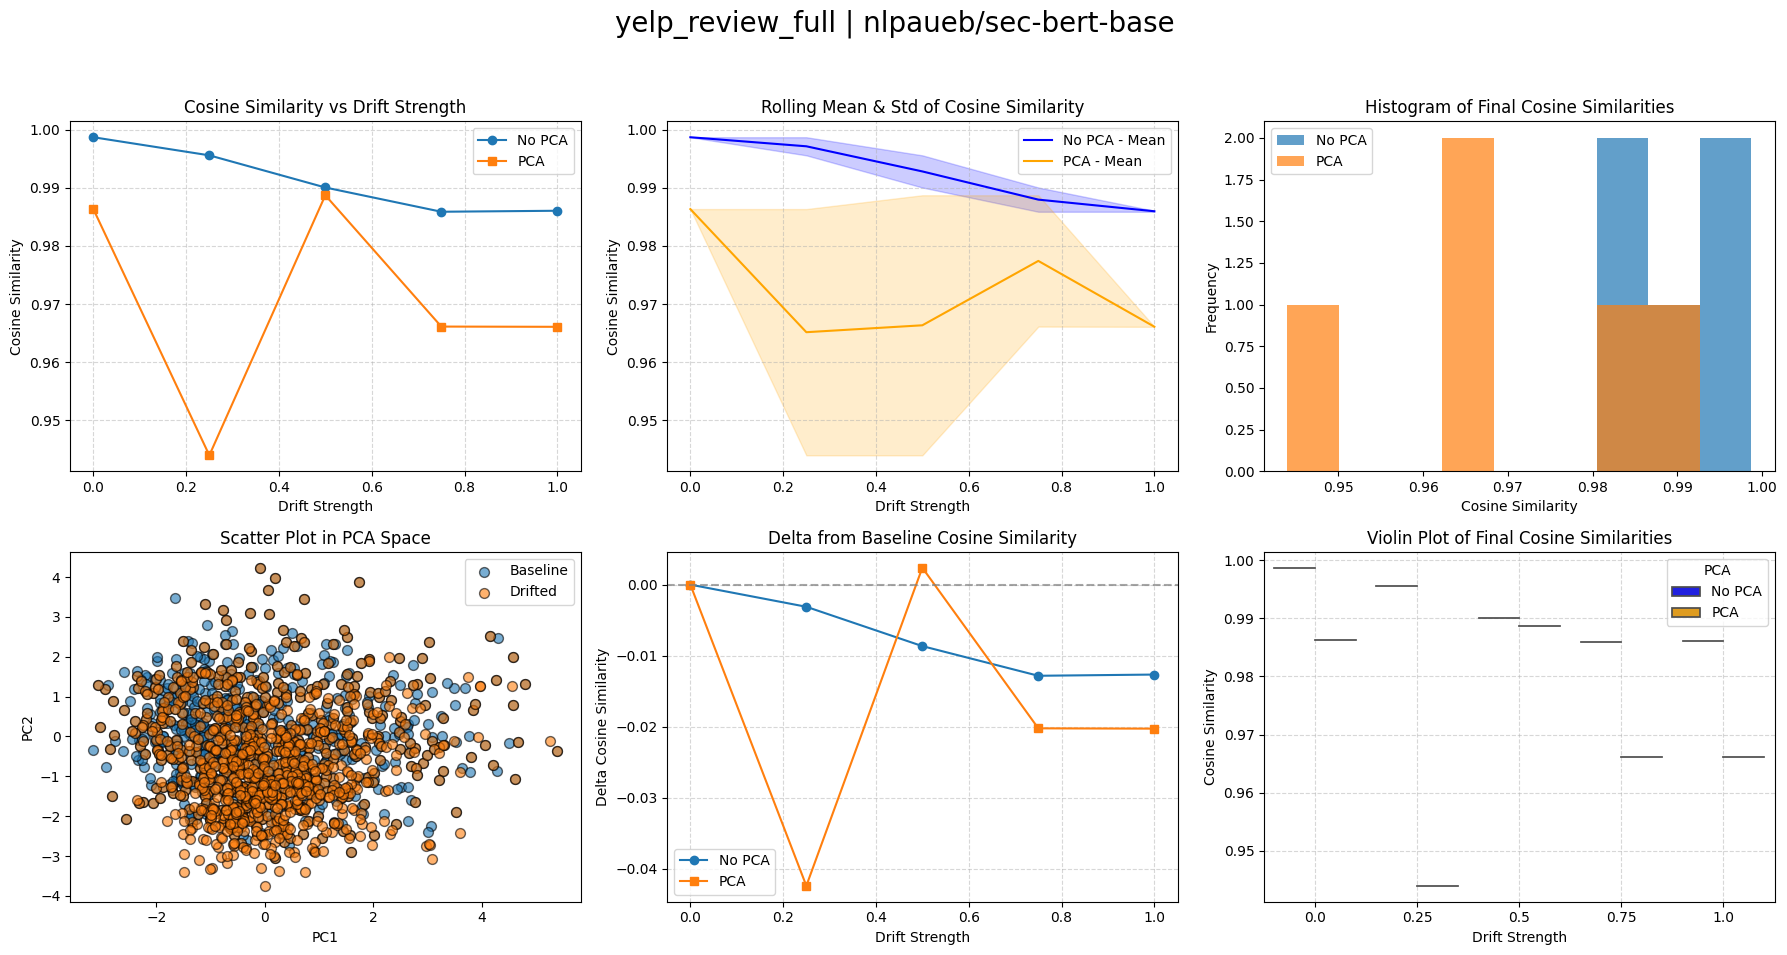

Saved 6-subplot figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_6subplots_cosine_similarity.png


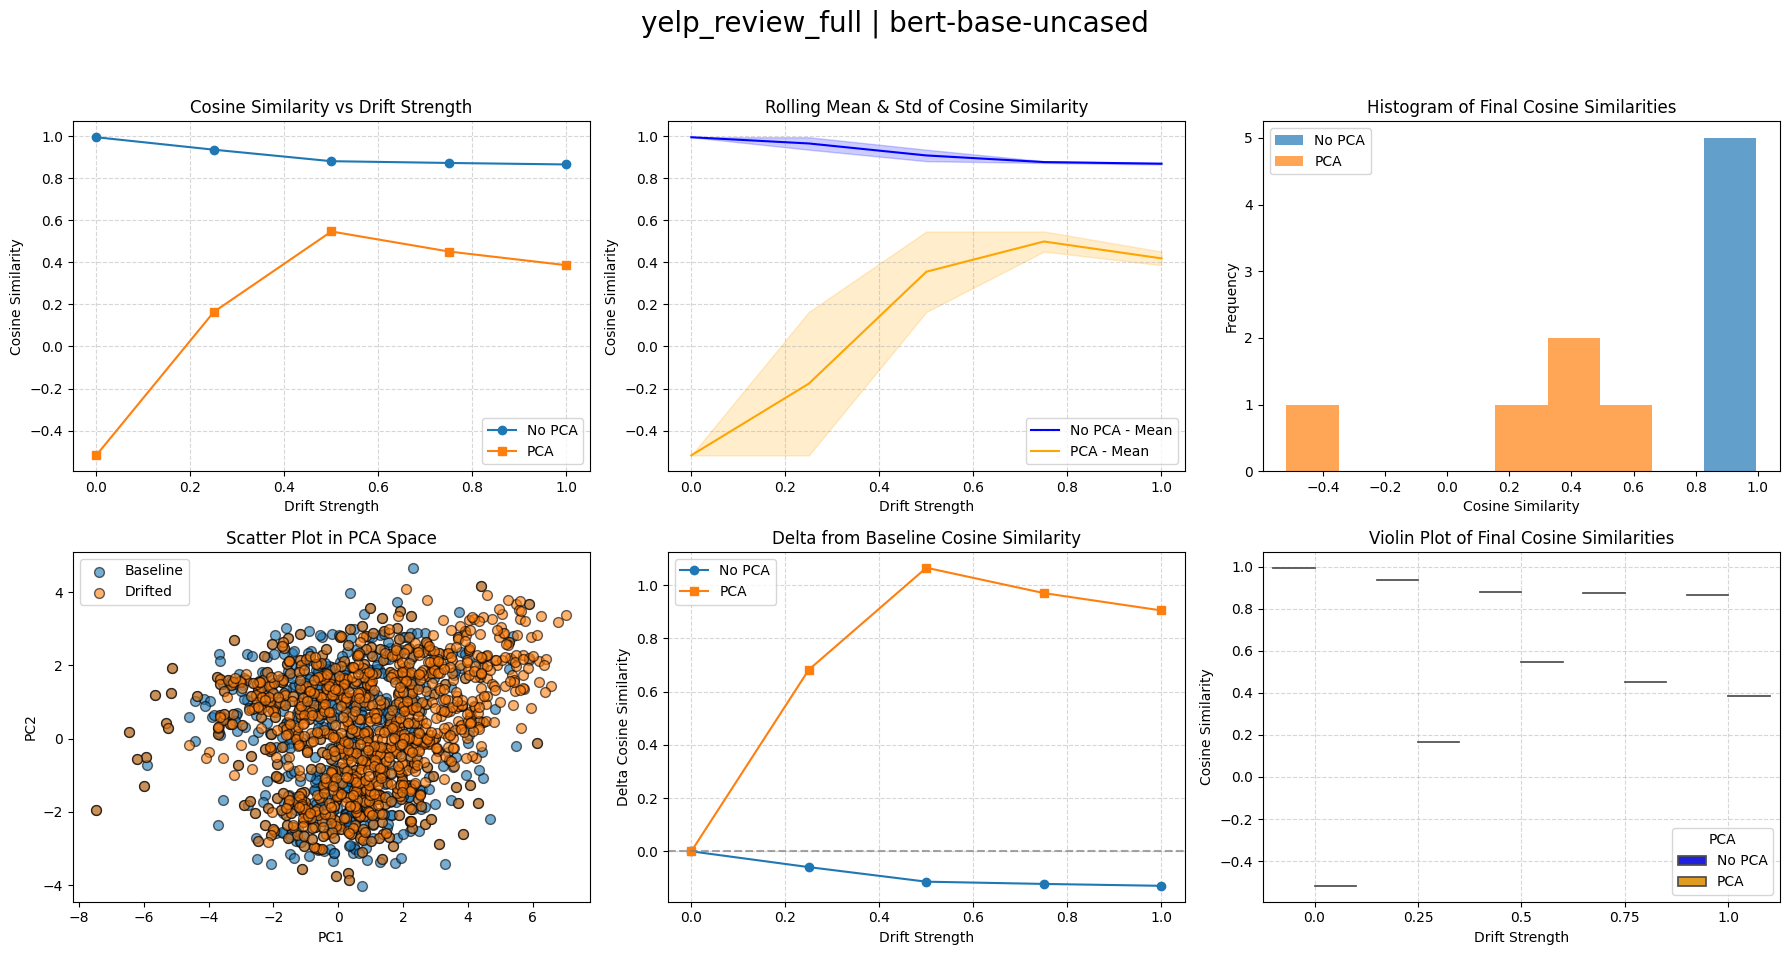

Saved 6-subplot figure: results_multidataset/yelp_review_full_bert-base-uncased_6subplots_cosine_similarity.png


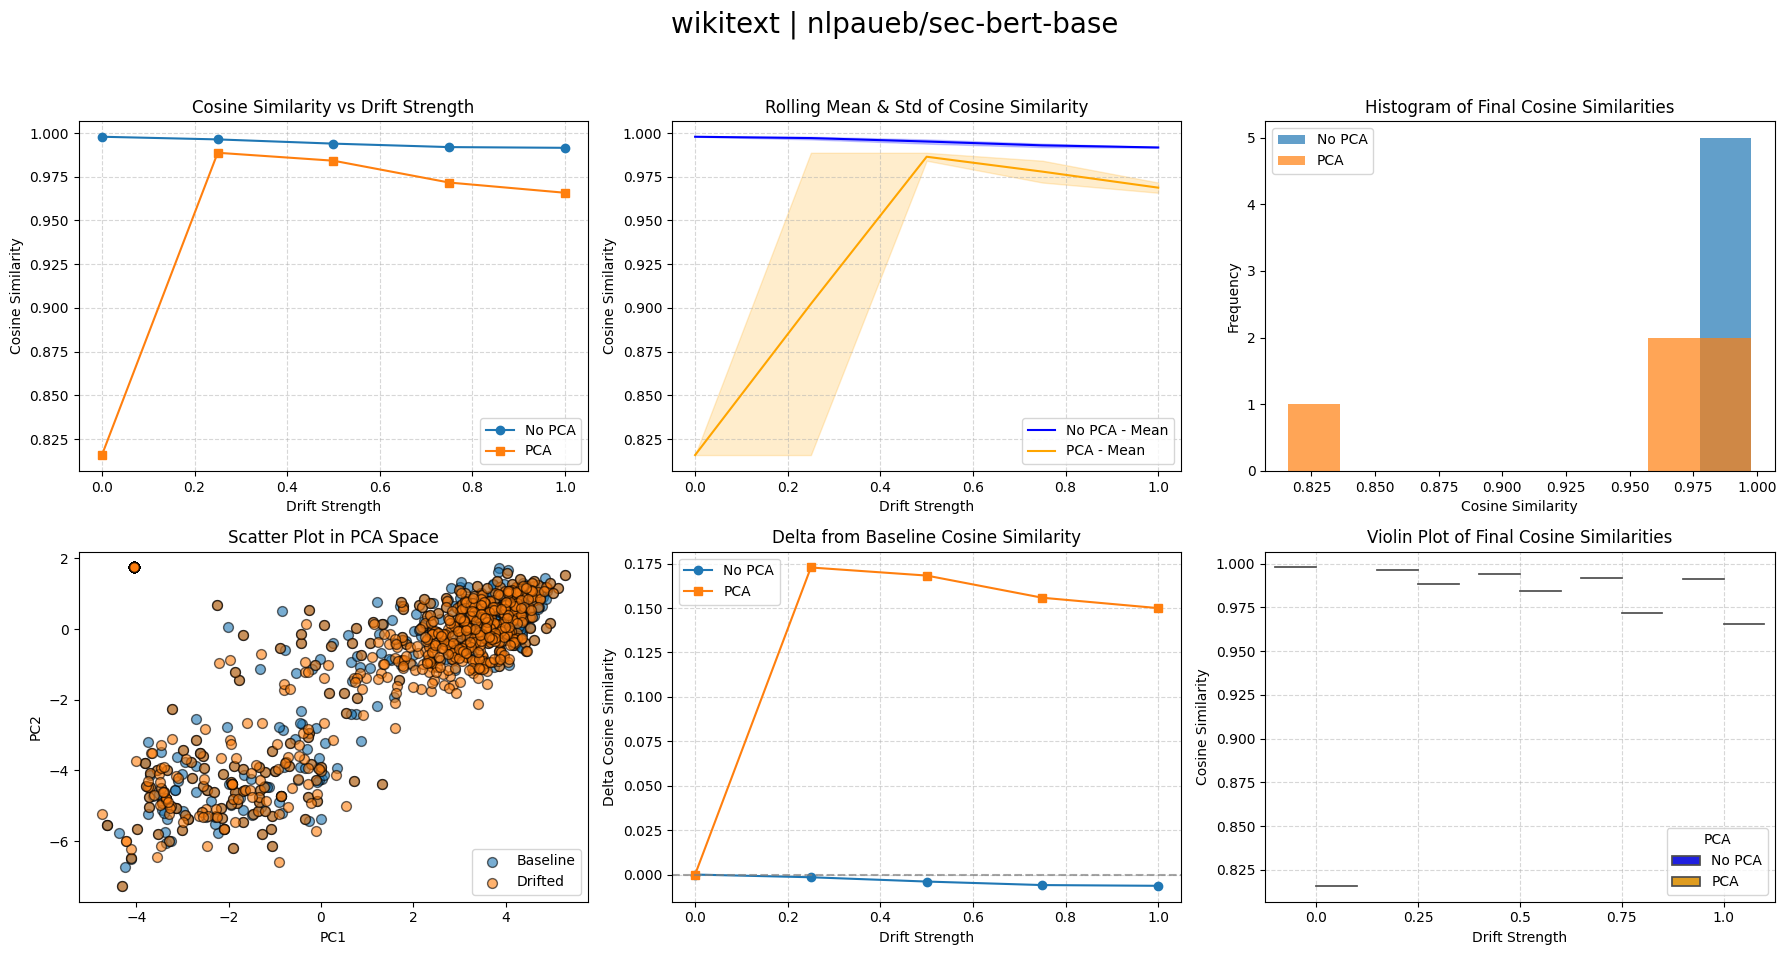

Saved 6-subplot figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_6subplots_cosine_similarity.png


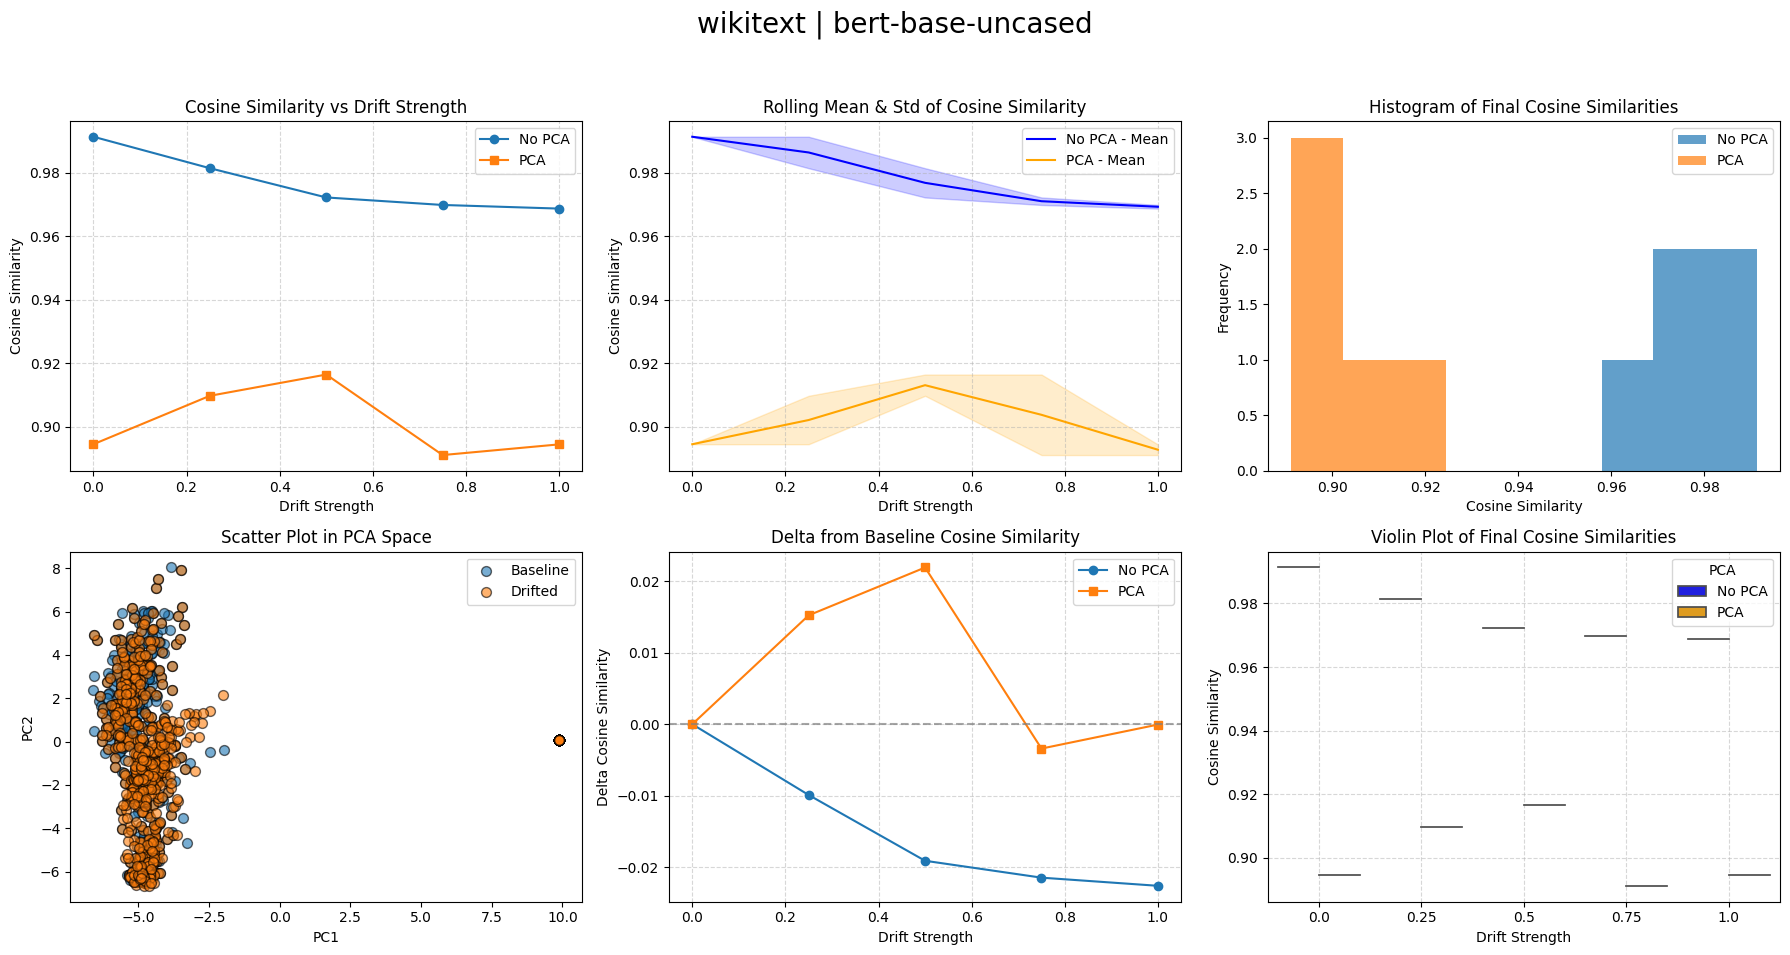

Saved 6-subplot figure: results_multidataset/wikitext_bert-base-uncased_6subplots_cosine_similarity.png


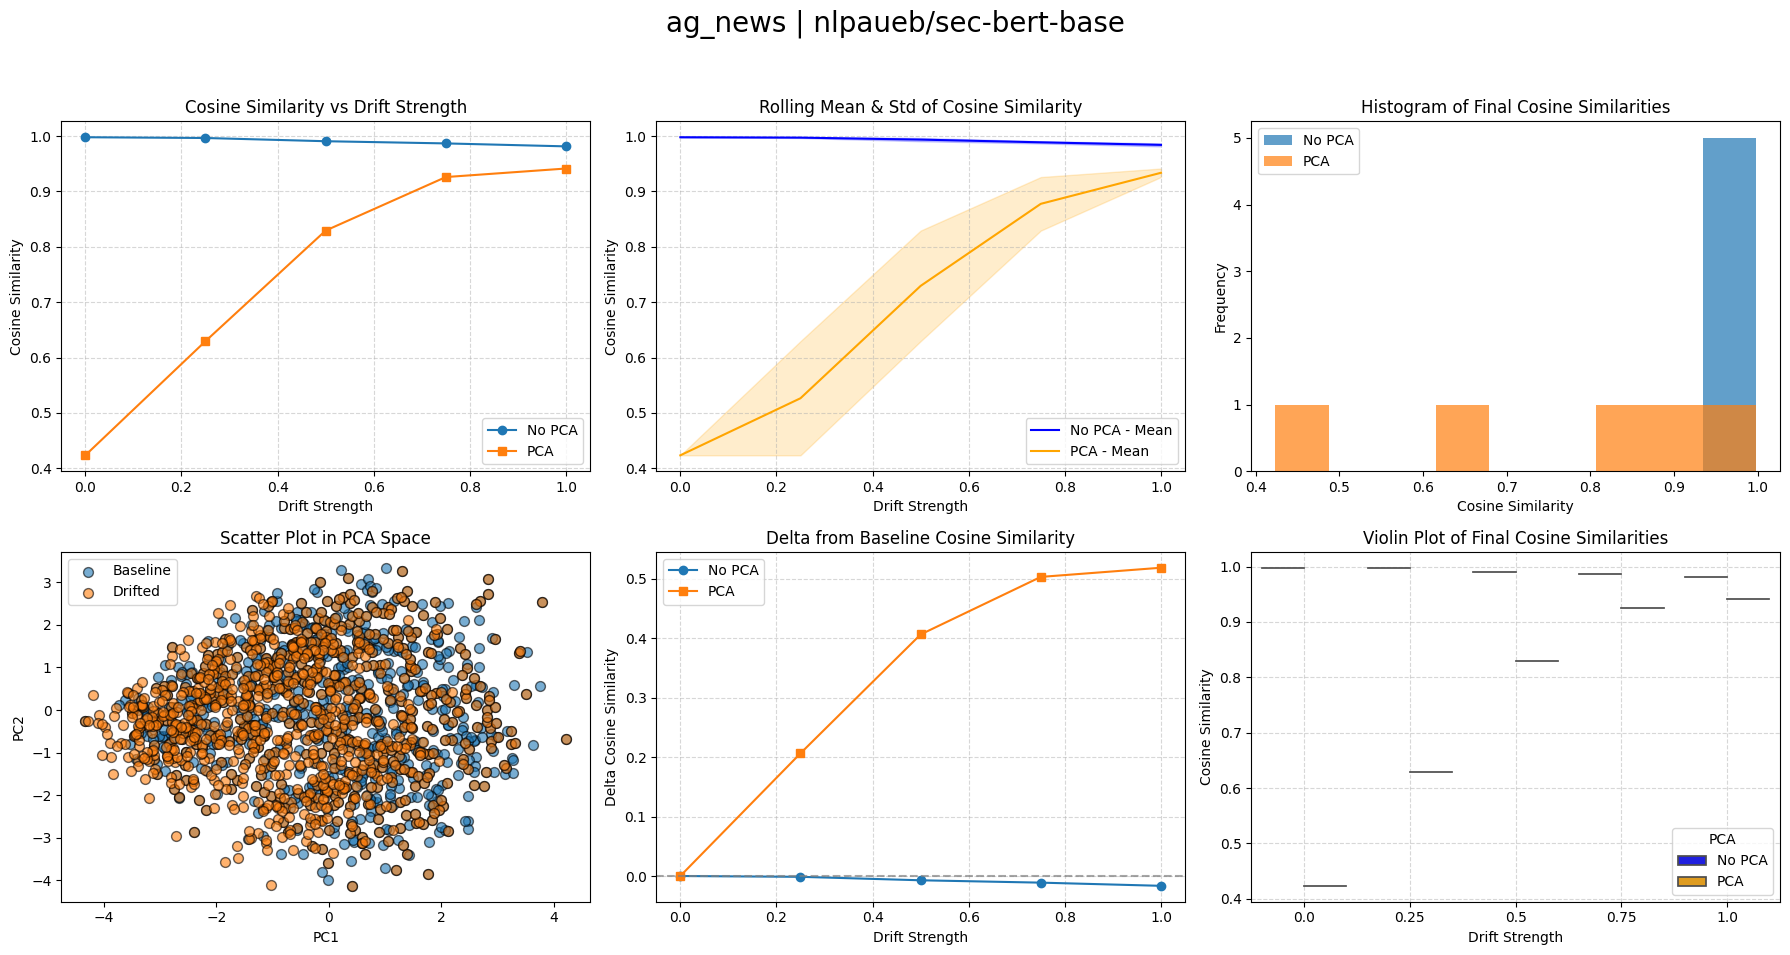

Saved 6-subplot figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_6subplots_cosine_similarity.png


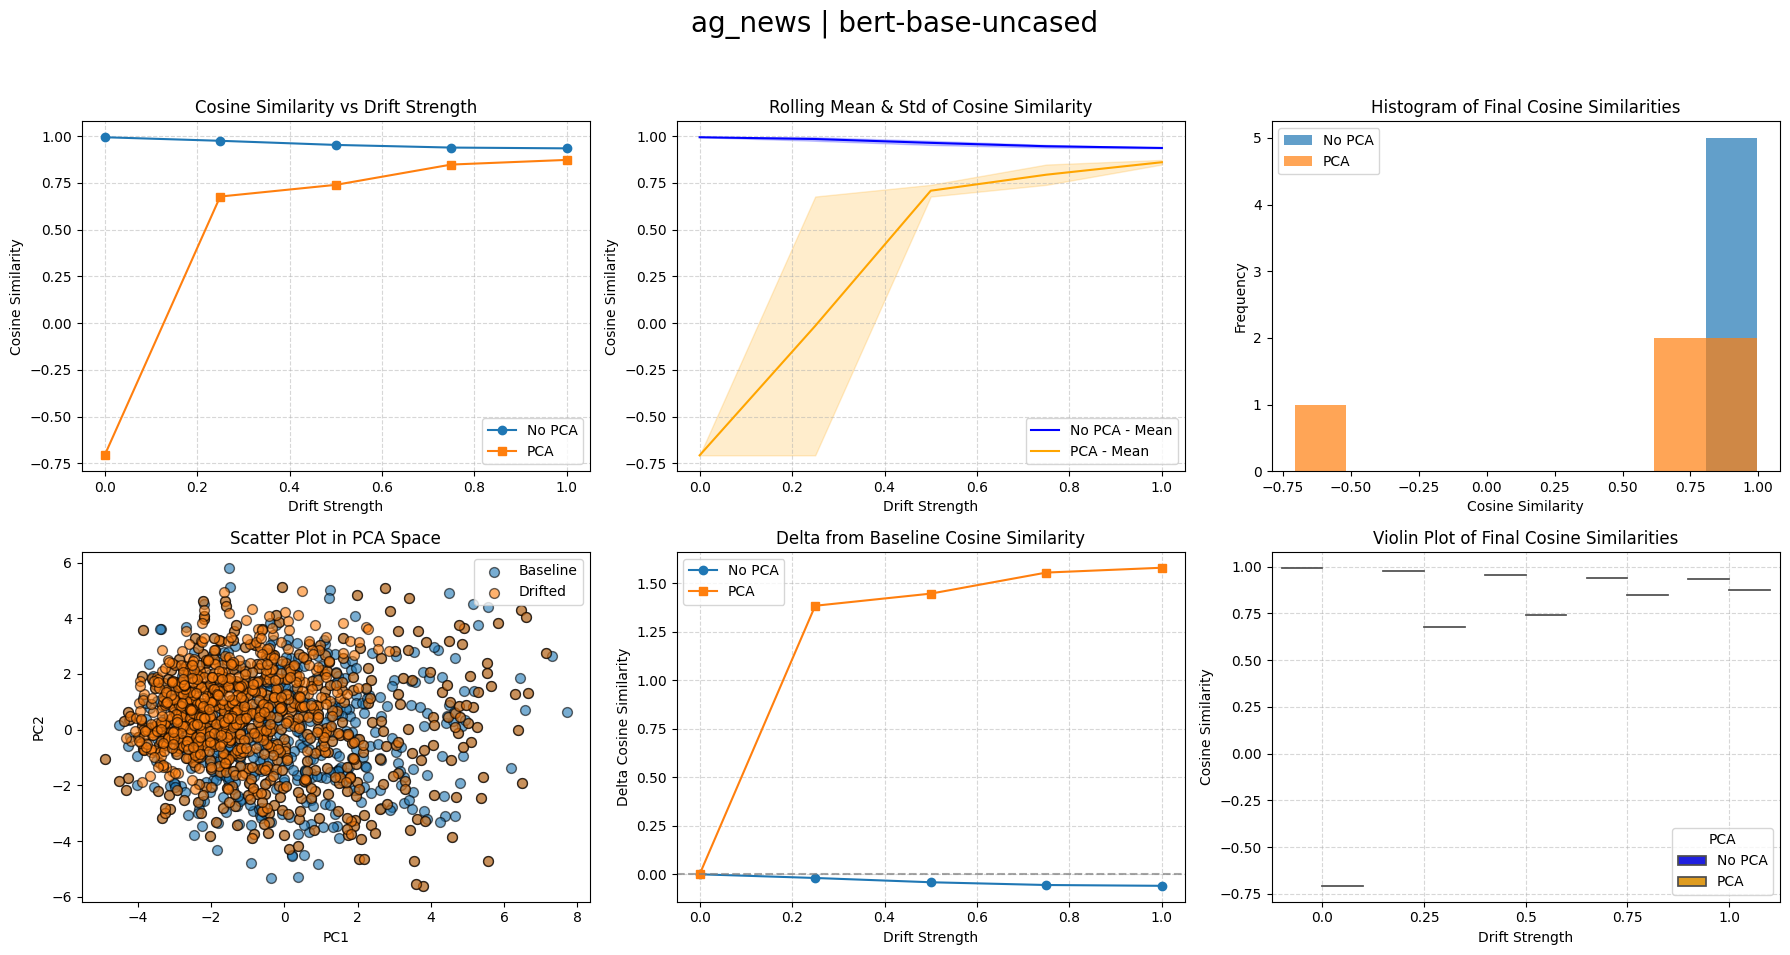

Saved 6-subplot figure: results_multidataset/ag_news_bert-base-uncased_6subplots_cosine_similarity.png
All done.


In [36]:
###############################################################################
# 2) Plotting: Reproduce 6 subplots, but using Cosine Similarity
###############################################################################
import matplotlib.pyplot as plt
import numpy as np

def plot_six_subplots(all_results, output_dir):
    """
    Plots six subplots for each dataset and model combination, replacing the sixth subplot
    with a violin plot for enhanced insights.

    :param all_results: Dictionary containing experiment results.
    :param output_dir: Directory where plots will be saved.
    """
    for (dataset_name, model_name), runs in all_results.items():
        no_pca = [r for r in runs if r["pca"] is False]
        pca_   = [r for r in runs if r["pca"] is True]

        no_pca = sorted(no_pca, key=lambda x: x["drift_strength"])
        pca_   = sorted(pca_,   key=lambda x: x["drift_strength"])

        x_no_pca = [r["drift_strength"] for r in no_pca]
        y_no_pca = [r["final_similarity"] for r in no_pca]
        x_pca    = [r["drift_strength"] for r in pca_]
        y_pca    = [r["final_similarity"] for r in pca_]

        def rolling_mean_std(values, window=2):
            means, stds = [], []
            for i in range(len(values)):
                wstart = max(0, i - window + 1)
                slice_ = values[wstart:i+1]
                means.append(np.mean(slice_))
                stds.append(np.std(slice_))
            return np.array(means), np.array(stds)

        y_no_pca_rm, y_no_pca_std = rolling_mean_std(y_no_pca, window=2)
        y_pca_rm,    y_pca_std    = rolling_mean_std(y_pca,    window=2)

        all_final_sims_no_pca = y_no_pca
        all_final_sims_pca    = y_pca

        # For largest drift strength
        baseline_run_no_pca = [r for r in no_pca if r["drift_strength"] == 0.0][0]
        drift_run_no_pca    = [r for r in no_pca if r["drift_strength"] == 1.0][0]
        baseline_run_pca    = [r for r in pca_   if r["drift_strength"] == 0.0][0]
        drift_run_pca       = [r for r in pca_   if r["drift_strength"] == 1.0][0]

        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        axs = axs.flatten()

        # 1) Cosine Similarity vs Drift Strength
        axs[0].plot(x_no_pca, y_no_pca, marker='o', label='No PCA')
        axs[0].plot(x_pca,    y_pca,    marker='s', label='PCA')
        axs[0].set_title("Cosine Similarity vs Drift Strength")
        axs[0].set_xlabel("Drift Strength")
        axs[0].set_ylabel("Cosine Similarity")
        axs[0].legend()
        axs[0].grid(True, linestyle='--', alpha=0.5)

        # 2) Rolling Mean & Std of Cosine Similarity
        axs[1].plot(x_no_pca, y_no_pca_rm, color='blue', label='No PCA - Mean')
        axs[1].fill_between(x_no_pca,
                            y_no_pca_rm - y_no_pca_std,
                            y_no_pca_rm + y_no_pca_std,
                            color='blue', alpha=0.2)

        axs[1].plot(x_pca, y_pca_rm, color='orange', label='PCA - Mean')
        axs[1].fill_between(x_pca,
                            y_pca_rm - y_pca_std,
                            y_pca_rm + y_pca_std,
                            color='orange', alpha=0.2)
        axs[1].set_title("Rolling Mean & Std of Cosine Similarity")
        axs[1].set_xlabel("Drift Strength")
        axs[1].set_ylabel("Cosine Similarity")
        axs[1].legend()
        axs[1].grid(True, linestyle='--', alpha=0.5)

        # 3) Histogram of Final Cosine Similarities
        combined_sims = all_final_sims_no_pca + all_final_sims_pca
        bins = np.linspace(min(combined_sims), max(combined_sims), 10)
        axs[2].hist(all_final_sims_no_pca, bins=bins, alpha=0.7, label='No PCA')
        axs[2].hist(all_final_sims_pca,    bins=bins, alpha=0.7, label='PCA')
        axs[2].set_title("Histogram of Final Cosine Similarities")
        axs[2].set_xlabel("Cosine Similarity")
        axs[2].set_ylabel("Frequency")
        axs[2].legend()

        # 4) Scatter Plot in PCA Space (Baseline vs Drifted)
        baseline_embs_2d = baseline_run_pca["all_embeddings"]
        drift_embs_2d    = drift_run_pca["all_embeddings"]
        axs[3].scatter(baseline_embs_2d[:, 0], baseline_embs_2d[:, 1],
                      alpha=0.6, label="Baseline", edgecolor='k', s=50)
        axs[3].scatter(drift_embs_2d[:, 0],    drift_embs_2d[:, 1],
                      alpha=0.6, label="Drifted", edgecolor='k', s=50)
        axs[3].set_title("Scatter Plot in PCA Space")
        axs[3].set_xlabel("PC1")
        axs[3].set_ylabel("PC2")
        axs[3].legend()

        # 5) Delta from Baseline Cosine Similarity
        baseline_dist_no_pca = baseline_run_no_pca["final_similarity"]
        baseline_dist_pca    = baseline_run_pca["final_similarity"]
        delta_no_pca = [dist - baseline_dist_no_pca for dist in y_no_pca]
        delta_pca    = [dist - baseline_dist_pca    for dist in y_pca]
        axs[4].plot(x_no_pca, delta_no_pca, marker='o', label='No PCA')
        axs[4].plot(x_pca,    delta_pca,    marker='s', label='PCA')
        axs[4].axhline(0.0, color='gray', linestyle='--', alpha=0.7)
        axs[4].set_title("Delta from Baseline Cosine Similarity")
        axs[4].set_xlabel("Drift Strength")
        axs[4].set_ylabel("Delta Cosine Similarity")
        axs[4].legend()
        axs[4].grid(True, linestyle='--', alpha=0.5)

        # 6) Violin Plot of Final Cosine Similarities by Drift Strength and PCA
        # Prepare data for seaborn
        data = []
        for r in no_pca:
            data.append({
                "Drift Strength": r["drift_strength"],
                "Cosine Similarity": r["final_similarity"],
                "PCA": "No PCA"
            })
        for r in pca_:
            data.append({
                "Drift Strength": r["drift_strength"],
                "Cosine Similarity": r["final_similarity"],
                "PCA": "PCA"
            })
        df_violin = pd.DataFrame(data)

        sns.violinplot(x="Drift Strength", y="Cosine Similarity",
                       hue="PCA", data=df_violin, split=True, ax=axs[5],
                       palette={"No PCA": "blue", "PCA": "orange"}, inner="quart")
        axs[5].set_title("Violin Plot of Final Cosine Similarities")
        axs[5].set_xlabel("Drift Strength")
        axs[5].set_ylabel("Cosine Similarity")
        axs[5].legend(title="PCA")
        axs[5].grid(True, linestyle='--', alpha=0.5)

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=20)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])

        # Ensure the output directory exists
        os.makedirs(output_dir, exist_ok=True)

        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_6subplots_cosine_similarity.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved 6-subplot figure: {save_path}")

plot_six_subplots(all_results, args["output_dir"])
print("All done.")


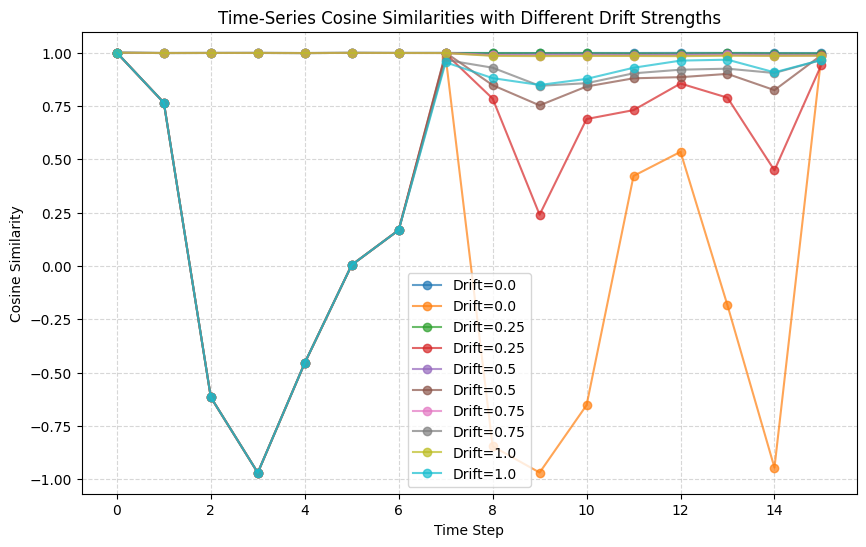

In [19]:
import matplotlib.pyplot as plt

def plot_time_series_similarity(runs):
    """
    runs: List of dicts from your data, each containing a 'drift_strength'
          and a 'time_series' of similarities over time.
    """
    plt.figure(figsize=(10, 6))
    for r in runs:
        strength = r["drift_strength"]
        # Convert to a normal Python list if needed
        ts_values = [float(x) for x in r["time_series"]]
        label = f"Drift={strength}"
        plt.plot(ts_values, marker='o', label=label, alpha=0.7)

    plt.title("Time-Series Cosine Similarities with Different Drift Strengths")
    plt.xlabel("Time Step")
    plt.ylabel("Cosine Similarity")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_time_series_similarity(all_results[("yelp_review_full", "nlpaueb/sec-bert-base")])


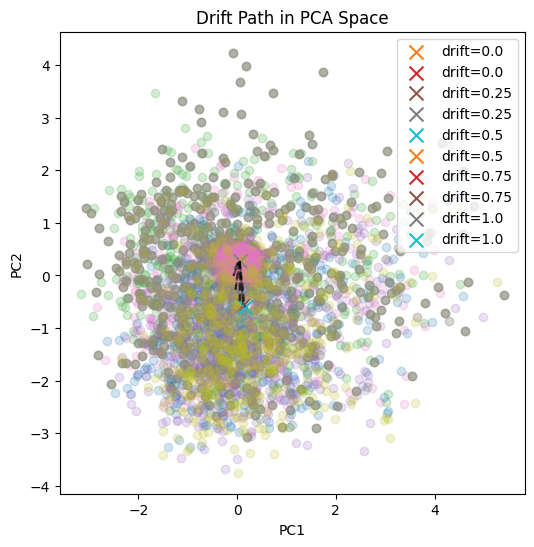

In [20]:
def plot_drift_path_2d(runs_pca):
    """
    runs_pca: sorted by drift_strength ascending, each has
              "all_embeddings" as an Nx2 array (PCA).
    """
    plt.figure(figsize=(6, 6))

    # Plot each drift’s mean coordinate to create a “path”:
    for i, r in enumerate(runs_pca):
        emb_2d = r["all_embeddings"]
        # 1) plot scatter of all points
        plt.scatter(emb_2d[:,0], emb_2d[:,1], alpha=0.2)
        # 2) plot mean
        mu = emb_2d.mean(axis=0)
        plt.scatter(mu[0], mu[1], marker='x', s=100,
                    label=f"drift={r['drift_strength']}")
        # Connect means with a line
        if i > 0:
            plt.plot([prev_mu[0], mu[0]], [prev_mu[1], mu[1]], 'k--', alpha=0.5)
        prev_mu = mu

    plt.title("Drift Path in PCA Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

plot_drift_path_2d(all_results[("yelp_review_full", "nlpaueb/sec-bert-base")])


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_20667/1421119434.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Drift Strength", y="Similarity", data=df, palette="Set2")


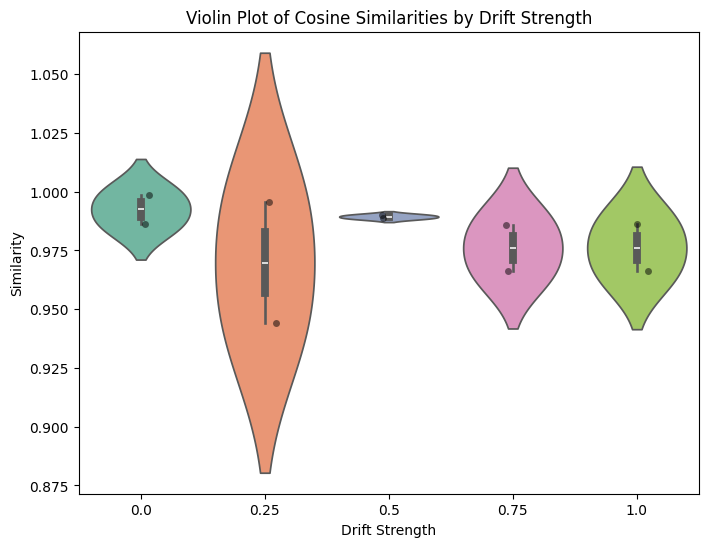

In [21]:
import seaborn as sns
import pandas as pd

def violin_plot_similarities(runs):
    # Construct a long-form DataFrame
    data = []
    for r in runs:
        drift = r["drift_strength"]
        final_sim = float(r["final_similarity"])
        # Or if you want to use all time steps, expand them
        # for t_val in r["time_series"]:
        #     data.append({"Drift Strength": drift, "Similarity": float(t_val)})
        data.append({"Drift Strength": drift, "Similarity": final_sim})
    df = pd.DataFrame(data)

    plt.figure(figsize=(8, 6))
    sns.violinplot(x="Drift Strength", y="Similarity", data=df, palette="Set2")
    sns.stripplot(x="Drift Strength", y="Similarity", data=df, color="k", alpha=0.5)
    plt.title("Violin Plot of Cosine Similarities by Drift Strength")
    plt.show()

violin_plot_similarities(all_results[("yelp_review_full", "nlpaueb/sec-bert-base")])

In [24]:
import seaborn as sns

def correlation_heatmap(baseline_embs, drifted_embs):
    import numpy as np
    combined = np.vstack([baseline_embs, drifted_embs])
    corr_mat = np.corrcoef(combined.T)  # correlation of features (d-dim)

    plt.figure(figsize=(8,6))
    sns.heatmap(corr_mat, cmap="RdBu_r", center=0)
    plt.title("Correlation Heatmap (Baseline + Drifted)")
    plt.show()



ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 768 and the array at index 1 has size 2

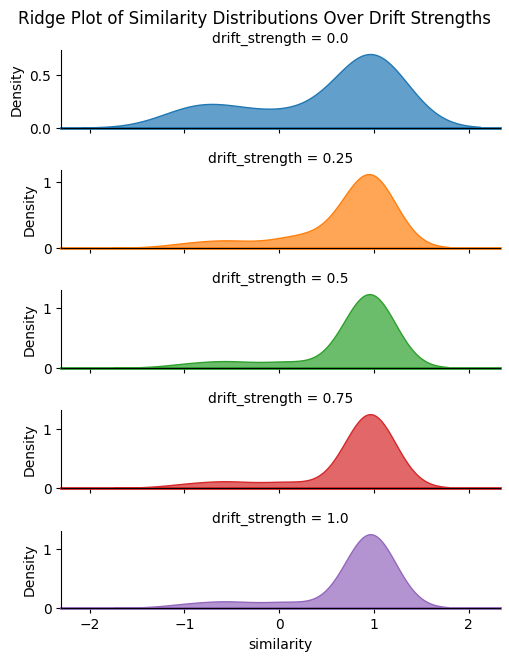

In [25]:
import seaborn as sns
import pandas as pd

def ridge_plot(runs):
    data = []
    for r in runs:
        drift = r["drift_strength"]
        for val in r["time_series"]:
            data.append({"drift_strength": drift, "similarity": float(val)})
    df = pd.DataFrame(data)

    # Sort drift strengths so the plot stacks in ascending order
    df["drift_strength"] = df["drift_strength"].astype("category")
    df = df.sort_values("drift_strength")

    # Create a 'FacetGrid' for a "ridge" style
    g = sns.FacetGrid(df, row="drift_strength", hue="drift_strength",
                      aspect=4, height=1.3, sharey=False)
    g.map(sns.kdeplot, "similarity", fill=True, alpha=0.7)
    g.map(plt.axhline, y=0, lw=2, clip_on=False)
    g.fig.suptitle("Ridge Plot of Similarity Distributions Over Drift Strengths", y=1.01)
    plt.show()

ridge_plot(all_results[("yelp_review_full", "nlpaueb/sec-bert-base")])

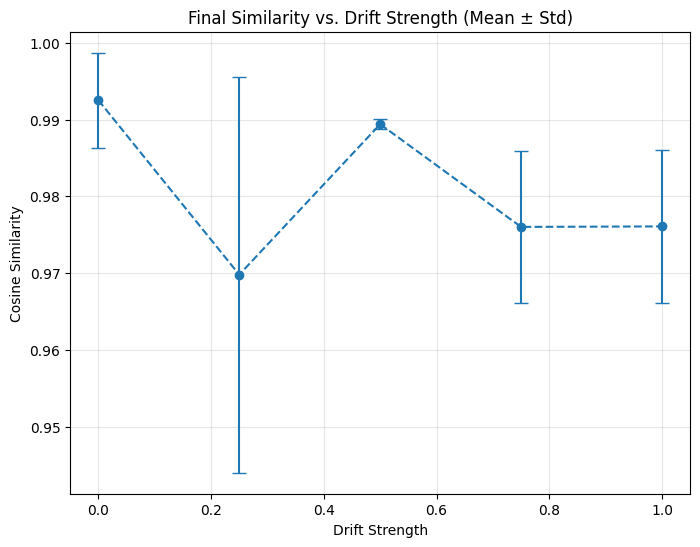

In [26]:
def errorbar_final_similarity(runs, n_repeats=5):
    # Example: assume multiple runs have the same 'drift_strength',
    # you group them to compute mean & std

    from collections import defaultdict
    grouped = defaultdict(list)
    for r in runs:
        grouped[r["drift_strength"]].append(float(r["final_similarity"]))

    x = sorted(grouped.keys())
    means = [np.mean(grouped[d]) for d in x]
    stds  = [np.std(grouped[d]) for d in x]

    plt.figure(figsize=(8,6))
    plt.errorbar(x, means, yerr=stds, fmt='o--', capsize=5)
    plt.title("Final Similarity vs. Drift Strength (Mean ± Std)")
    plt.xlabel("Drift Strength")
    plt.ylabel("Cosine Similarity")
    plt.grid(True, alpha=0.3)
    plt.show()

errorbar_final_similarity(all_results[("yelp_review_full", "nlpaueb/sec-bert-base")])

In [27]:
from sklearn.decomposition import PCA

def scree_plot_comparison(baseline_embs, drifted_embs, n_components=10):
    pca_baseline = PCA(n_components=n_components).fit(baseline_embs)
    pca_drifted  = PCA(n_components=n_components).fit(drifted_embs)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.bar(range(1,n_components+1), pca_baseline.explained_variance_ratio_*100)
    plt.title("Baseline PCA Scree")
    plt.xlabel("Principal Component")
    plt.ylabel("Variance Explained (%)")

    plt.subplot(1,2,2)
    plt.bar(range(1,n_components+1), pca_drifted.explained_variance_ratio_*100, color='orange')
    plt.title("Drifted PCA Scree")
    plt.xlabel("Principal Component")
    plt.ylabel("Variance Explained (%)")

    plt.tight_layout()
    plt.show()



ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=2 with svd_solver='covariance_eigh'

In [ ]:
import pandas as pd
from pandas.plotting import parallel_coordinates

def parallel_coords_plot(baseline_embs, drifted_embs):
    n_dims = baseline_embs.shape[1]
    baseline_mean = baseline_embs.mean(axis=0)
    drifted_mean  = drifted_embs.mean(axis=0)

    # Make DataFrame with repeated rows so parallel_coords can interpret
    df_data = np.vstack([baseline_mean, drifted_mean])
    df = pd.DataFrame(df_data, columns=[f"Dim_{i}" for i in range(n_dims)])
    df["Type"] = ["Baseline", "Drifted"]

    plt.figure(figsize=(10, 4))
    parallel_coordinates(df, class_column="Type", color=["blue", "orange"])
    plt.title("Parallel Coordinates of Mean Embedding (Baseline vs. Drifted)")
    plt.grid(True, alpha=0.3)
    plt.show()
